In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 25.2 MB/s eta 0:00:00


**Imports**

In [ ]:
from google.colab import drive
import zipfile
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

In [ ]:
# torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader , Dataset,random_split
from torchmetrics.classification import BinaryAccuracy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import resnet50, ResNet50_Weights

**Load data**

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_file_path = '/content/drive/MyDrive/Shop DataSet.zip'
extract_directory = '/content'

os.makedirs(extract_directory, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_directory)

In [ ]:
shop_lifters_path="/content/Shop DataSet/shop lifters"
shop_nonlifters_path="/content/Shop DataSet/non shop lifters"

In [ ]:
shop_lifters = [os.path.join(shop_lifters_path,i) for i in os.listdir(shop_lifters_path)]
shop_nonlifters = [os.path.join(shop_nonlifters_path,i) for i in os.listdir(shop_nonlifters_path)]

**EDA on data**

In [ ]:
print(len(shop_lifters))
print(len(shop_nonlifters))

324
531


In [ ]:
def number_frames(video_path):
  cap = cv2.VideoCapture(video_path)
  frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
  cap.release()
  return frame_count

In [ ]:
def number_fps(video_path):
  cap = cv2.VideoCapture(video_path)
  fps = int(cap.get(cv2.CAP_PROP_FPS))
  cap.release()
  return fps

In [ ]:
shop_lifters_frames = [
    number_frames(i)
    for i in shop_lifters
]

shop_nonlifters_frames = [
    number_frames(i)
    for i in shop_nonlifters
]
shop_lifters_fps = [
    number_fps(i)
    for i in shop_lifters
]

shop_nonlifters_fps = [
    number_fps(i)
    for i in shop_nonlifters
]

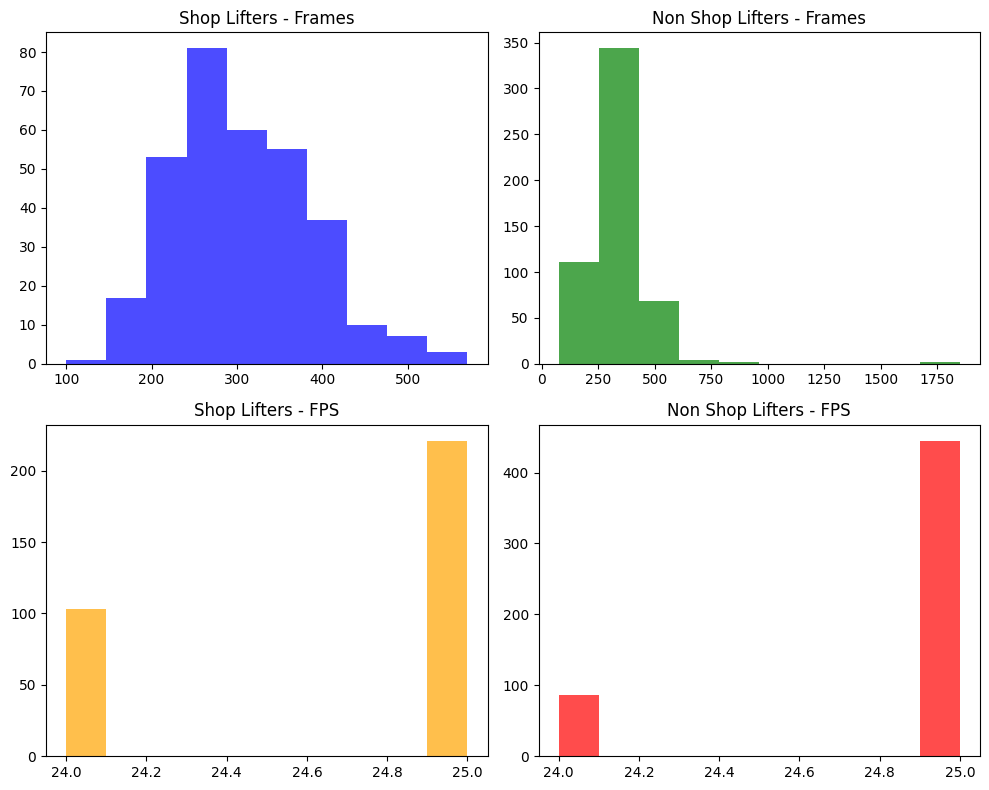

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(shop_lifters_frames, bins=10, color='blue', alpha=0.7)
axes[0, 0].set_title("Shop Lifters - Frames")

axes[0, 1].hist(shop_nonlifters_frames, bins=10, color='green', alpha=0.7)
axes[0, 1].set_title("Non Shop Lifters - Frames")

axes[1, 0].hist(shop_lifters_fps, bins=10, color='orange', alpha=0.7)
axes[1, 0].set_title("Shop Lifters - FPS")

axes[1, 1].hist(shop_nonlifters_fps, bins=10, color='red', alpha=0.7)
axes[1, 1].set_title("Non Shop Lifters - FPS")

plt.tight_layout()
plt.show()

In [ ]:
print(set(shop_lifters_fps))
print(set(shop_nonlifters_fps))

{24, 25}
{24, 25}


**prepare data and splite data into train test**

In [ ]:
class Shop_Dataset(Dataset):
    def __init__(self, shop_lifters, shop_nonlifters, transform=None):
        self.shop_lifters = shop_lifters
        self.shop_nonlifters = shop_nonlifters
        self.transform = transform

    def __len__(self):
        return len(self.shop_lifters) + len(self.shop_nonlifters)

    def __getitem__(self, idx):

        if idx < len(self.shop_lifters):
            video_path = self.shop_lifters[idx]
            label = 1
        else:
            video_path = self.shop_nonlifters[idx - len(self.shop_lifters)]
            label = 0

        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        indices = np.linspace(0, total_frames - 1, 16, dtype=int)
        frames = []

        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if not ret:
                continue
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = Image.fromarray(frame)
            if self.transform:
                frame = self.transform(frame)
            frames.append(frame)

        cap.release()

        frames = torch.stack(frames)

        label = torch.tensor(label, dtype=torch.long)

        return frames, label

In [ ]:
# frame size (576, 704, 3)
tranform = transforms.Compose([
    transforms.Resize((256 , 256)),
    transforms.ToTensor()
])

In [ ]:
dataset = Shop_Dataset(shop_lifters, shop_nonlifters, transform=tranform)

In [ ]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model = nn.Sequential(*list(model.children())[:-1])
model.eval().cuda()

dataset_embedd = []

with torch.no_grad():
    for vid, label in dataset:   # assume vid: Tensor [num_frames, 3, H, W]
        # batch process all frames at once
        vid = vid.cuda()

        # Forward pass all frames in one go
        features = model(vid)                # (num_frames, 2048, 1, 1)
        features = features.view(features.size(0), -1)  # (num_frames, 2048)

        dataset_embedd.append(features.cpu())

print(f"Number of videos embedded: {len(dataset_embedd)}")
print(f"Shape of first video embeddings: {dataset_embedd[0][0].shape}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 194MB/s]


Number of videos embedded: 855
Shape of first video embeddings: torch.Size([2048])


In [ ]:
video_tensors = []
for vid_embedd in dataset_embedd:
    frames_tensor = torch.stack([f.squeeze() for f in vid_embedd])
    video_tensors.append(frames_tensor)

# take the first video as reference
reference_video = video_tensors[0][0]

# compute cosine similarity per video
similarities = []
for vid_tensor in video_tensors:
    frame_sims = F.cosine_similarity(reference_video, vid_tensor)

    sim = frame_sims.mean().item()
    similarities.append(sim)

for i, sim in enumerate(similarities):
    print(f"Video {i}: Cosine similarity = {sim:.4f}")

Video 0: Cosine similarity = 0.9887
Video 1: Cosine similarity = 0.9464
Video 2: Cosine similarity = 0.9573
Video 3: Cosine similarity = 0.9376
Video 4: Cosine similarity = 0.9501
Video 5: Cosine similarity = 0.9206
Video 6: Cosine similarity = 0.9503
Video 7: Cosine similarity = 0.9511
Video 8: Cosine similarity = 0.9776
Video 9: Cosine similarity = 0.9381
Video 10: Cosine similarity = 0.9256
Video 11: Cosine similarity = 0.9845
Video 12: Cosine similarity = 0.9506
Video 13: Cosine similarity = 0.9499
Video 14: Cosine similarity = 0.9283
Video 15: Cosine similarity = 0.9436
Video 16: Cosine similarity = 0.9178
Video 17: Cosine similarity = 0.9200
Video 18: Cosine similarity = 0.8961
Video 19: Cosine similarity = 0.9775
Video 20: Cosine similarity = 0.9819
Video 21: Cosine similarity = 0.9393
Video 22: Cosine similarity = 0.9900
Video 23: Cosine similarity = 0.9101
Video 24: Cosine similarity = 0.9583
Video 25: Cosine similarity = 0.9360
Video 26: Cosine similarity = 0.9516
Video 27: C

In [ ]:
np.percentile(similarities,90)

np.float64(0.9599928140640259)

In [ ]:
threshold = 0.985
video_vectors = [v for v in video_tensors]
n = len(video_vectors)

keep_indices = []
removed_indices = set()

for i in range(n):
    if i in removed_indices:
        continue
    vi = video_vectors[i]
    keep_indices.append(i)

    for j in range(i + 1, n):
        if j in removed_indices:
            continue

        vj = video_vectors[j]

        frame_sims = F.cosine_similarity(vi, vj, dim=1)
        sim = frame_sims.mean().item()

        if sim > threshold:
            removed_indices.add(j)

cleaned_dataset = [dataset_embedd[i] for i in keep_indices]
removed_items = [dataset_embedd[i] for i in removed_indices]

print(f" Kept {len(cleaned_dataset)} videos, removed {len(removed_items)} duplicates.")

 Kept 307 videos, removed 548 duplicates.


In [ ]:
removed_indices = set(removed_indices)  # O(n), done once
cleaned_dataset = [item for i, item in enumerate(dataset) if i not in removed_indices]


In [ ]:
len(cleaned_dataset)

307

In [ ]:
train_size = int(0.8 * len(cleaned_dataset))
val_size=len(cleaned_dataset)-train_size
train_dataset,val_dataset = random_split(cleaned_dataset, [train_size,val_size])

In [ ]:
print(f"size of train dataset is {len(train_dataset)}")
print(f"size of val dataset is {len(val_dataset)}")

size of train dataset is 245
size of val dataset is 62


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=True)

In [ ]:
batch = next(iter(train_loader))
image, label = batch
#[8, 32, 3, 224, 224]
#batch size , number of frames , channels , width , hight
print("Images type:", type(image))
print("Images shape:", image.shape)
print("Images dtype:", image.dtype)

print("Label type:", type(label))
print("Label shape:", label.shape)
print("Label value:", label)

Images type: <class 'torch.Tensor'>
Images shape: torch.Size([8, 16, 3, 256, 256])
Images dtype: torch.float32
Label type: <class 'torch.Tensor'>
Label shape: torch.Size([8])
Label value: tensor([1, 1, 0, 0, 0, 1, 0, 0])


**model**

In [ ]:
class VideoModel(nn.Module):
    def __init__(self, hidden_size, num_layers, dropout=0.3):
        super(VideoModel, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(dropout),


            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Global Average Pooling to reduce [B, 512, 7, 7] → [B, 512]
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # ----- GRU for temporal modeling -----
        self.gru = nn.GRU(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # ----- Fully Connected (Classification) -----
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: [batch, frames, 3, 224, 224]
        B, frames, C, H, W = x.shape
        cnn_features = []

        for f_idx in range(frames):
            frame = x[:, f_idx, :, :, :]         # [B, 3, 224, 224]
            f = self.cnn(frame)                  # [B, 512, 7, 7]
            f = f.view(B, -1)                    # [B, 512]
            cnn_features.append(f)

        # Stack all frames → [B, frames, 512]
        feats = torch.stack(cnn_features, dim=1)

        # GRU output
        out, _ = self.gru(feats)                 # [B, frames, hidden_size]
        out = out[:, -1, :]                      # take last frame output
        out = self.fc(out)                       # [B, 1]

        return out


pretrained Model

**training loop**

In [ ]:
def fit(num_epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = VideoModel(hidden_size=32, num_layers=1, dropout=0.5).to(device)
    criterion = nn.BCEWithLogitsLoss()
    accuracy_metric = BinaryAccuracy().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.000001)
    l1_norm=1e-5
    best_val_loss = float('inf')  # initialize high value

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        epoch_loss, epoch_acc = 0.0, 0.0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            preds = model(images)
            loss_value = criterion(preds, labels.unsqueeze(1).float())+l1_norm*sum(p.abs().sum() for p in model.parameters())
            loss_value.backward()
            optimizer.step()

            preds = torch.sigmoid(preds)
            acc = accuracy_metric(preds, labels.unsqueeze(1).float())

            epoch_loss += loss_value.item()
            epoch_acc += acc.item()

        epoch_loss /= len(train_loader)
        epoch_acc /= len(train_loader)

        # ----- VALIDATION -----
        model.eval()
        val_loss, val_acc = 0.0, 0.0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
                images, labels = images.to(device), labels.to(device)
                preds = model(images)
                loss_value = criterion(preds, labels.unsqueeze(1).float())
                preds = torch.sigmoid(preds)
                acc = accuracy_metric(preds, labels.unsqueeze(1).float())

                val_loss += loss_value.item()
                val_acc += acc.item()

        val_loss /= len(val_loader)
        val_acc /= len(val_loader)
        if val_loss < best_val_loss:
          best_val_loss = val_loss
          torch.save(model.state_dict(), "cnn_gru.pth")

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    return model, history


In [ ]:
def visualize_metrics(history):
  plt.plot(history["train_loss"], label="Train Loss")
  plt.plot(history["val_loss"], label="Val Loss")
  plt.legend()
  plt.title("Loss")
  plt.show()


  plt.plot(history["train_acc"], label="Train Acc")
  plt.plot(history["val_acc"], label="Val Acc")
  plt.legend()
  plt.title("Accuracy")
  plt.show()

**Model Fit**

In [ ]:
model,history = fit(num_epochs=100)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch [1/100] | Train Loss: 0.9637, Acc: 0.4702 | Val Loss: 0.6955, Acc: 0.5312


Epoch [2/100] | Train Loss: 0.9638, Acc: 0.4702 | Val Loss: 0.6967, Acc: 0.5208


Epoch [3/100] | Train Loss: 0.9621, Acc: 0.4702 | Val Loss: 0.6950, Acc: 0.5208


Epoch [4/100] | Train Loss: 0.9599, Acc: 0.4726 | Val Loss: 0.6898, Acc: 0.5365


...

Epoch [96/100] | Train Loss: 0.7153, Acc: 0.8871 | Val Loss: 0.4473, Acc: 0.8906


Epoch [97/100] | Train Loss: 0.7391, Acc: 0.8548 | Val Loss: 0.4365, Acc: 0.9115


Epoch [98/100] | Train Loss: 0.7230, Acc: 0.8605 | Val Loss: 0.4272, Acc: 0.8906


Epoch [99/100] | Train Loss: 0.7277, Acc: 0.8645 | Val Loss: 0.4595, Acc: 0.7604


Epoch [100/100] | Train Loss: 0.7281, Acc: 0.8565 | Val Loss: 0.4876, Acc: 0.7344


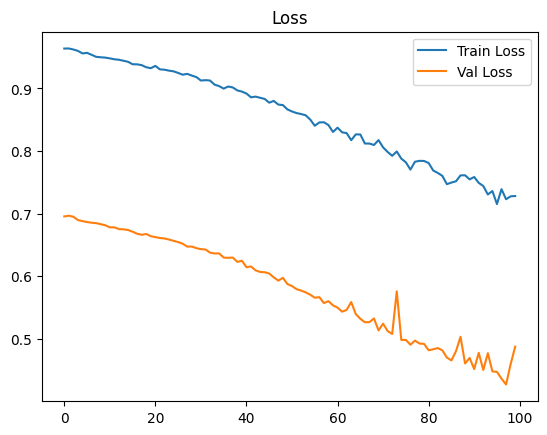

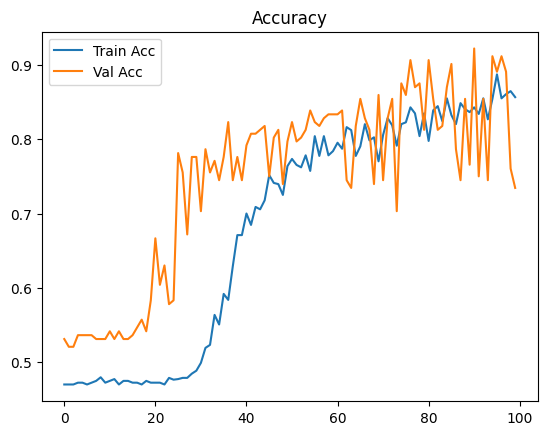

In [ ]:
visualize_metrics(history)